In [19]:
import numpy as np
import pandas as pd
# import json
# import os
from collections import defaultdict
from itertools import combinations
import pickle

from scipy import stats
from scipy.stats import pearsonr
import pickle
# import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, make_scorer

from scipy.stats import ttest_rel
from scipy.stats import linregress

# from xgboost import XGBRegressor


In [20]:
reps = defaultdict(dict)

DIR = "/home/ines/Downloads/file_ines"
for model in ['fs_rf', 'fs_svm', 'fs_knn', 'fs_gb', 'fs_combo_rf', 'fs_combo_svm', 'fs_combo_knn', 'fs_combo_gb',  'fs_synth_rf', 'fs_synth_svm', 'fs_synth_knn', 'fs_synth_gb',
'fs_doublecombo_rf', 'fs_doublecombo_svm', 'fs_doublecombo_knn', 'fs_doublecombo_gb',
'hbn_rf', 'hbn_svm', 'hbn_knn', 'hbn_gb', 'hbn_synth_rf', 'hbn_synth_svm', 'hbn_synth_knn', 'hbn_synth_gb', 'hbn_combo_rf', 'hbn_combo_svm', 'hbn_combo_knn', 'hbn_combo_gb',
'hbn_doublecombo_rf', 'hbn_doublecombo_svm', 'hbn_doublecombo_knn', 'hbn_doublecombo_gb',
'fs_knn_neighbour_k2', 'hbn_knn_neighbour_k2', 'fs_knn_neighbour_k5', 'hbn_knn_neighbour_k5' ]:

    # if model in ['fs_rf', 'fs_svm', 'fs_knn']: continue
    
    if model in ['fs_rf', 'fs_svm', 'fs_knn', 'fs_gb', 'fs_combo_rf', 'fs_combo_svm', 'fs_combo_knn', 'fs_combo_gb']:
        # rep = pickle.load(open(f"final/mae_reps_{model}_final.pkl", 'rb'))
        # reps[model] = rep   
        if model in ['fs_rf', 'fs_svm', 'fs_knn', 'fs_gb']: rep = pickle.load(open(f"{DIR}/mae_reps_{model.split('_')[-1]}_final.pkl", "rb"))
        else: rep = pickle.load(open(f"{DIR}/mae_reps_combined_{model.split('_')[-1]}.pkl", 'rb'))
        reduced_rf = {}

        for k, values in rep.items():
            N = int(k)

            combs_16 = list(combinations(range(16), N))
            combs_15 = set(combinations(range(15), N))

            reduced_rf[k] = [
                v for c, v in zip(combs_16, values)
                if c in combs_15
            ]

        reps[model] = reduced_rf 
    elif model in ['hbn_rf', 'hbn_svm', 'hbn_knn', 'hbn_gb']:
        reps[model] = pickle.load(open(f"{DIR}/mae_reps_{model.split('_')[-1]}_hbn.pkl", 'rb')) #arel's data
    elif model in ['hbn_synth_rf', 'hbn_synth_svm', 'hbn_synth_knn', 'hbn_synth_gb']:
        # reps[model] = pickle.load(open(f"final/mae_reps_synthetic_gaussian_{model.split('_')[-1]}_hbn_complete.pkl", 'rb')) #old
        reps[model] = pickle.load(open(f"{DIR}/mae_reps_synthetic_gaussian_{model.split('_')[-1]}_rep15_hbn.pkl", 'rb')) 
    elif model in ['fs_synth_rf', 'fs_synth_svm', 'fs_synth_knn', 'fs_synth_gb']:
        # reps[model] = pickle.load(open(f"{DIR}/mae_reps_synthetic_gaussian_{model.split('_')[-1]}_fs.pkl", 'rb')) 
        reps[model] = pickle.load(open(f"/home/ines/Downloads/cnn_train_data/mae_reps_synthetic_gaussian_{model.split('_')[-1]}_fs_rep15.pkl", 'rb')) 
        
    elif model in [ 'hbn_combo_rf', 'hbn_combo_svm', 'hbn_combo_knn', 'hbn_combo_gb' ]:
        reps[model] = pickle.load(open(f"{DIR}/mae_reps_combined_{model.split('_')[-1]}_hbn.pkl", 'rb')) 
    elif model in [ 'hbn_doublecombo_rf', 'hbn_doublecombo_svm', 'hbn_doublecombo_knn', 'hbn_doublecombo_gb', ]:
        reps[model] = pickle.load(open(f"{DIR}/mae_reps_doublecombined_{model.split('_')[-1]}_hbn.pkl", 'rb')) 
    elif model in [ 'fs_doublecombo_rf', 'fs_doublecombo_svm', 'fs_doublecombo_knn', 'fs_doublecombo_gb' ]:
        reps[model] = pickle.load(open(f"{DIR}/mae_reps_doublecombined_{model.split('_')[-1]}_fs.pkl", 'rb')) 
    elif model in ['fs_knn_neighbour', 'hbn_knn_neighbour']:
        reps[model] = pickle.load(open(f"{DIR}/mae_reps_{model.split('_')[0]}_knn_neighbours.pkl", 'rb')) 
    elif model in ['fs_knn_neighbour_k2', 'hbn_knn_neighbour_k2']:
        reps[model] = pickle.load(open(f"{DIR}/mae_reps_{model.split('_')[0]}_knn_neighbours_k2.pkl", 'rb')) 
    elif model in ['fs_knn_neighbour_k5', 'hbn_knn_neighbour_k5']:
        reps[model] = pickle.load(open(f"{DIR}/mae_reps_{model.split('_')[0]}_knn_neighbours_k5.pkl", 'rb')) 


## Exploration of Synthetic Bug

In [32]:
def create_subjectID(dataset, subject):
    if dataset == "ADNI_TEST":
        return subject
    elif dataset in ["OAS1", "OAS2"]:
        return subject.split("_MR")[0]
    elif dataset == 'LA5C':
        return f"{dataset}_{subject.split('-')[1]}"
    elif dataset in ['ABIDEI', 'MIRIAD']:
        return f"{dataset}_{subject.split('_')[1]}"
    else:
        return f"{dataset}_{subject}"


def load_and_process_csvs():
    # Load datasets
    test = pd.read_csv('/home/inesgp/cnn_training/fastsurfer_small_test.csv')
    test["Subject"] = test.apply(lambda row: create_subjectID(row["Dataset"], row["Subject ID"]), axis=1)
    
    train = pd.read_csv('/home/inesgp/cnn_training/fastsurfer_small_train.csv')
    train = train.drop(train.loc[ (train['Subject ID'] == 'miriad_221_6_MR_2') ].index) #no multiple sessions
    train["Subject"] = train.apply(lambda row: create_subjectID(row["Dataset"], row["Subject ID"]), axis=1)

    brain_age = pd.concat([test, train])

    brain_age = brain_age.drop(brain_age.loc[ (brain_age['Subject ID'] == 'OAS2_0117_MR4') ].index) #no multiple sessions
    
    # Load ROI volumes
    df = pd.read_csv('/home/inesgp/cnn_training/final/roi_volumes_final.csv')
    df = (
        df.groupby("Subject", group_keys=False)
        .apply(lambda g: g.loc[:, g.sum() != 0])
    )

    df["Subject"] = df["Subject"].apply(lambda x: str(x).split(".")[0]) 
    df = df.drop(df.loc[ (df['Subject'] == 'HCP_211417') & (df['Split'] == 'test') ].index) #duplicate
    df = df.drop(df.loc[ (df['Subject'] == 'OAS2_0117') & (df['Split'] == 'test') ].index) #duplicate
    df = df.drop(df.loc[ (df['Subject'] == 'MIRIAD_221_6') ].index) #extra session
    
    return df, brain_age


def prepare_features_targets(df, brain_age):
    feature_rows, target, datasets = [], {}, []
    
    for sub in df['Subject'].unique():
        if 'sub' in sub: continue #MICA subject doesn't have ages
        # print(sub, df.loc[df['Subject'] == sub].drop(columns=['Subject']).shape)
        feature_rows.append( df.loc[df['Subject'] == sub].drop(columns=['Subject', 'Split']) )
        if sub == 'MIRIAD_221_5': sub = 'MIRIAD_221'
        target[sub] = [brain_age.loc[brain_age['Subject'] == sub]['Age'].item()] * 16
        datasets.append([brain_age.loc[brain_age['Subject'] == sub]['Dataset'].item()] * 16)
    
    feature_rows = np.array(feature_rows, dtype=np.float32)
    y = np.array(list(target.values()))
    datasets = np.array(datasets)

    # Move to GPU
    # feature_rows_gpu = cp.array(feature_rows)  # (280, N, 95)
    # y_gpu = cp.array(y)             # (280, N)

    # print(feature_rows_gpu.shape, y.shape)
    
    groups = np.repeat(list(target.keys()), 1)
    
    gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    train_idx, test_idx = next(gss.split(feature_rows, y, groups=groups))
    
    X_train, X_test = feature_rows[train_idx], feature_rows[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    datasets_train, datasets_test = datasets[train_idx], datasets[test_idx]

    # df_features = pd.DataFrame(feature_rows[:, 0, :], columns=[f'ROI_{i}' for i in range(feature_rows.shape[2])])
    df_features = []
    for i in range(feature_rows.shape[1]): #repetitions
        tmp = pd.DataFrame(X_train[:,i], columns=[f'ROI_{i}' for i in range(feature_rows.shape[2])])
        tmp['Age'] = y_train[:, i].flatten() 
        tmp['Dataset'] = datasets_train[:, i].flatten() 
        df_features.append( tmp )
        
    print('Final prep shapes', X_train.shape, X_test.shape, len(df_features), y_train.shape)
    
    return df_features, X_train, X_test, y_train, y_test


In [33]:
df, brain_age = load_and_process_csvs()
df_features, X_train, X_test, y_train, y_test = prepare_features_targets(df, brain_age)

/tmp/ipykernel_838642/1383286044.py:31: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Final prep shapes (376, 16, 95) (42, 16, 95) 16 (376, 16)


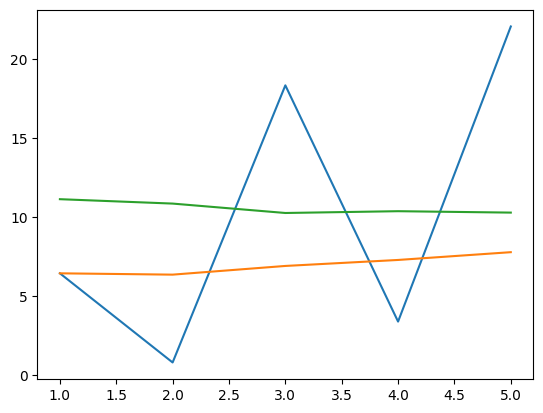

In [74]:
a = {0: 31.0, 1: [6.435855865478516, 6.435855865478516, 6.435855865478516, 6.435855865478516, 6.435855865478516], 2: [0.791309165954587, 0.791309165954587, 0.791309165954587, 0.791309165954587, 0.791309165954587, 0.791309165954587, 0.791309165954587, 0.791309165954587, 0.791309165954587, 0.791309165954587], 3: [18.336314392089847, 18.336314392089847, 18.336314392089847, 18.336314392089847, 18.336314392089847, 18.336314392089847, 18.336314392089847, 18.336314392089847, 18.336314392089847, 18.336314392089847], 4: [3.3803939819335938, 3.3803939819335938, 3.3803939819335938, 3.3803939819335938, 3.3803939819335938], 5: [22.063091278076172], }
b = {0: 31.0, 1: [6.435855865478516, 6.435855865478516, 6.435855865478516, 6.435855865478516, 6.435855865478516], 2: [6.35215950012207, 6.35215950012207, 6.35215950012207, 6.35215950012207, 6.35215950012207, 6.35215950012207, 6.35215950012207, 6.35215950012207, 6.35215950012207, 6.35215950012207], 3: [6.902675628662109, 6.902675628662109, 6.902675628662109, 6.902675628662109, 6.902675628662109, 6.902675628662109, 6.902675628662109, 6.902675628662109, 6.902675628662109, 6.902675628662109], 4: [7.281887054443359, 7.281887054443359, 7.281887054443359, 7.281887054443359, 7.281887054443359], 5: [7.774188995361328], }
c = {0: 31.0, 1: [11.128811257370721, 11.128811257370721, 11.128811257370721, 11.128811257370721, 11.128811257370721], 2: [10.85074793739246, 10.85074793739246, 10.85074793739246, 10.85074793739246, 10.85074793739246, 10.85074793739246, 10.85074793739246, 10.85074793739246, 10.85074793739246, 10.85074793739246], 3: [10.255373614319574, 10.255373614319574, 10.255373614319574, 10.255373614319574, 10.255373614319574, 10.255373614319574, 10.255373614319574, 10.255373614319574, 10.255373614319574, 10.255373614319574], 4: [10.368795133916946, 10.368795133916946, 10.368795133916946, 10.368795133916946, 10.368795133916946], 5: [10.279728038115001],}

for i in a: 
    a[i] = np.mean(a[i])
    b[i] = np.mean(b[i])
    c[i] = np.mean(c[i])

plt.plot(np.arange(1,6), list(a.values())[1:])
plt.plot(np.arange(1,6), list(b.values())[1:])
plt.plot(np.arange(1,6), list(c.values())[1:])


In [57]:
X_train.shape

def heatmap_data(data):
    fig, axes = plt.subplots(8, 2, figsize=(15, 15), sharex=True, sharey=True)
    axes = axes.flatten()

    # Create a single normalization range so all plots share the same scale
    vmin = np.min(data)
    vmax = 150000 #np.max(data)

    # Plot heatmaps (no individual colorbars)
    for i in range(16):
        sns.heatmap(
            data[:, i, :],
            ax=axes[i],
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            cbar=False
        )
        axes[i].set_title(f"Repetition {i}")
        axes[i].axis("off")

    # Adjust layout to make space at bottom
    plt.subplots_adjust(bottom=0.08, hspace=0.2, wspace=0.1)

    # Create horizontal colorbar axis at bottom
    cbar_ax = fig.add_axes([0.2, -0.03, 0.6, 0.02])  
    # [left, bottom, width, height]

    sm = plt.cm.ScalarMappable(cmap="viridis")
    sm.set_clim(vmin, vmax)

    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("Value")

    plt.tight_layout()
    plt.show()



/tmp/ipykernel_838642/3508883367.py:37: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



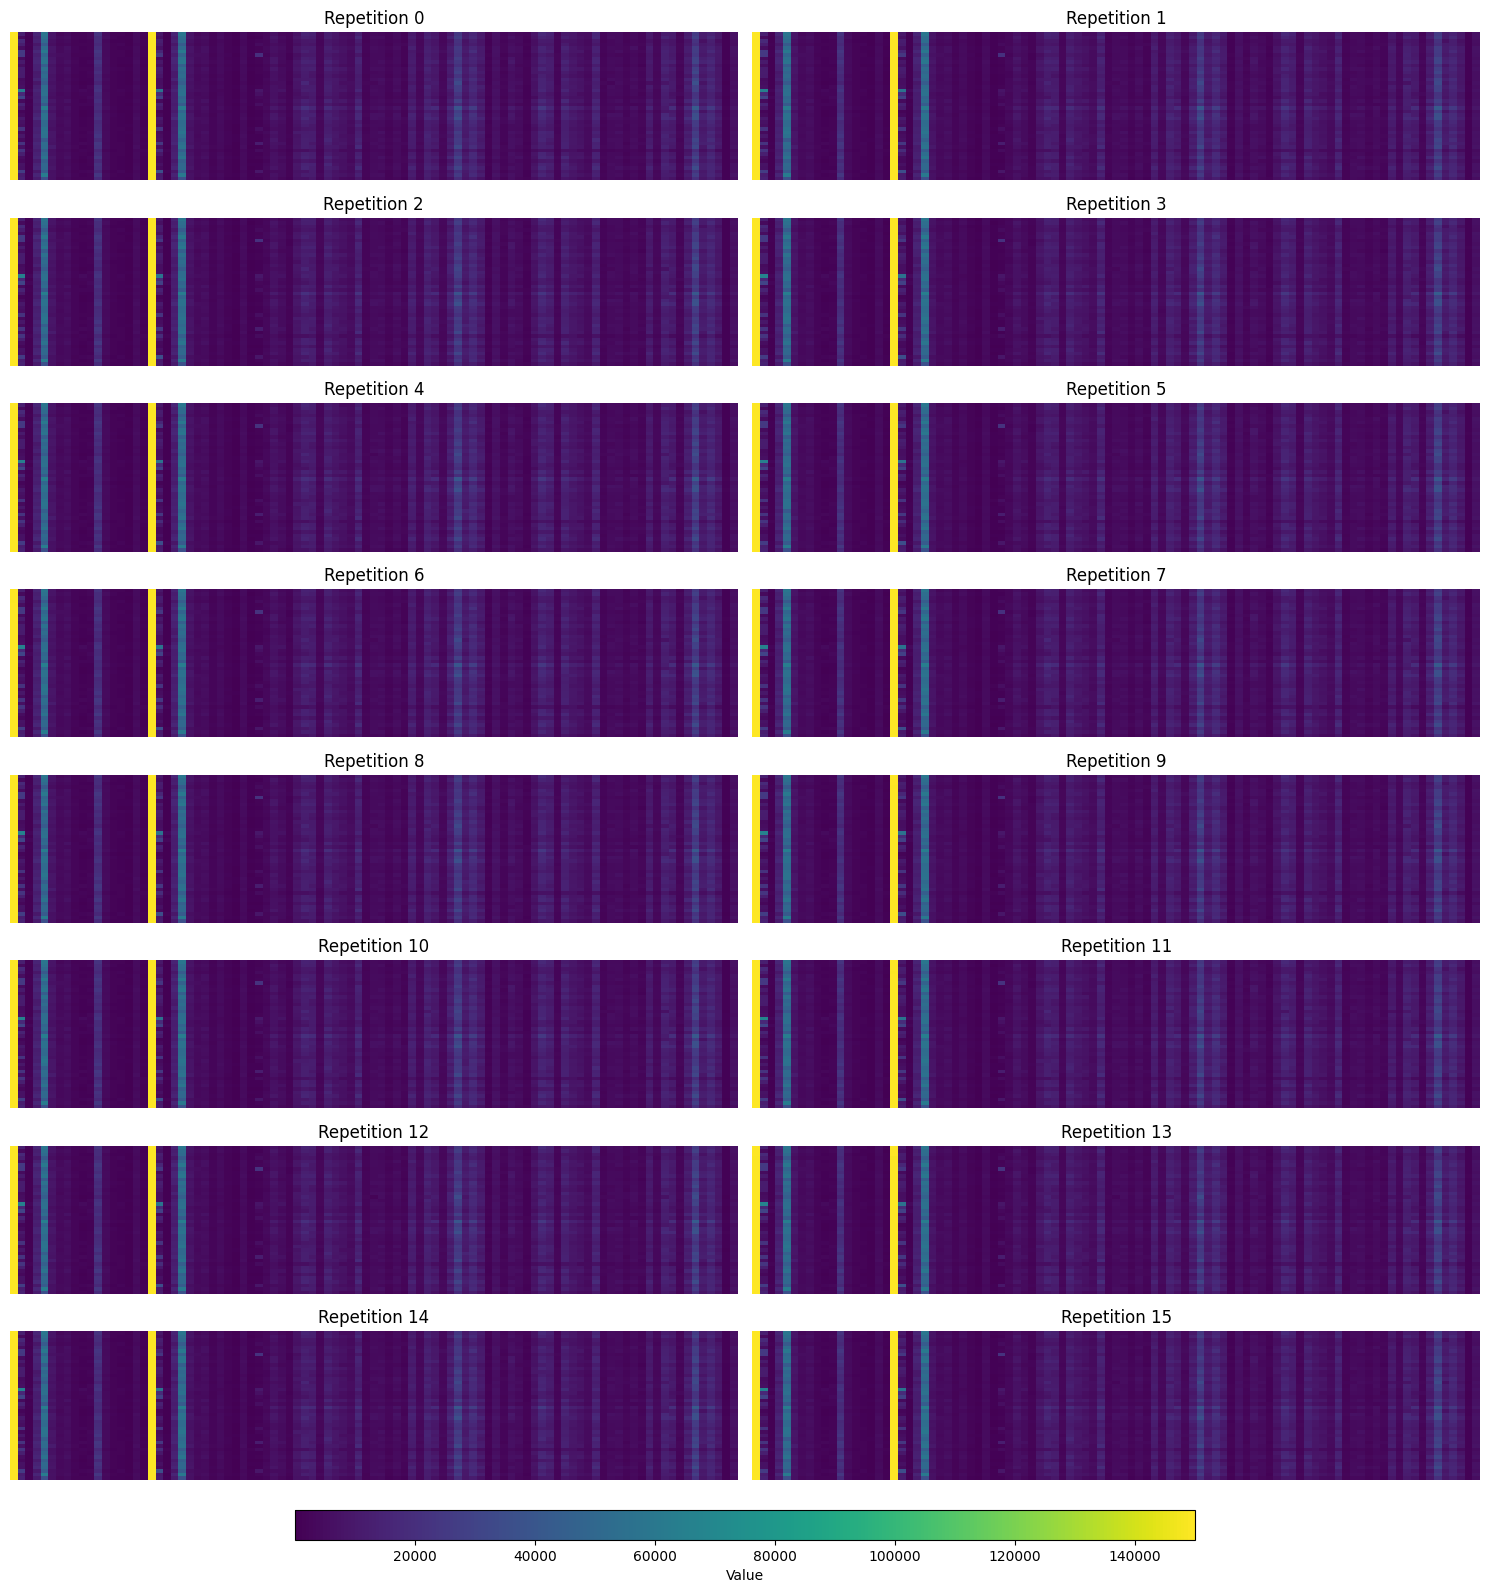

In [58]:
heatmap_data(X_test)

In [65]:
# # ========== OPTION 1: Histogram by repetition (Plotly) ==========
# fig = go.Figure()

# for rep in range(X_test.shape[1]):
#     rep_data = X_test[:, rep, :].flatten()
#     fig.add_trace(go.Histogram(
#         x=rep_data,
#         name=f'Repetition {rep}',
#         opacity=0.7,
#         nbinsx=30
#     ))

# fig.update_layout(
#     title="Distribution of Values by Repetition",
#     xaxis_title="Value",
#     yaxis_title="Frequency",
#     barmode='overlay',
#     height=600,
#     width=1000
# )
# fig.show()

# # ========== OPTION 2: Violin plot by repetition ==========
# data_flat = []
# reps = []
# for rep in range(X_test.shape[1]):
#     rep_data = X_test[:, rep, :].flatten()
#     data_flat.extend(rep_data)
#     reps.extend([f'Rep {rep}'] * len(rep_data))

# df_plot = pd.DataFrame({'Value': data_flat, 'Repetition': reps})

# fig = px.violin(df_plot, y='Value', x='Repetition', box=True, points=False)
# fig.update_layout(
#     title="Distribution of Values by Repetition (Violin Plot)",
#     height=600,
#     width=1200
# )
# fig.show()

# ========== OPTION 3: Statistics summary ==========
data = X_train
print("Value Statistics Across All Data:")
print(f"Mean: {data.mean():.4f}")
print(f"Std: {data.std():.4f}")
print(f"Min: {data.min():.4f}")
print(f"Max: {data.max():.4f}")
print(f"Median: {np.median(data):.4f}")

print("\nStatistics by Repetition:")
for rep in range(data.shape[1]):
    rep_data = data[:, rep, :].flatten()
    print(f"Rep {rep}: mean={rep_data.mean():.4f}, std={rep_data.std():.4f}")

Value Statistics Across All Data:
Mean: 12343.0322
Std: 32843.2109
Min: 0.0000
Max: 335569.0000
Median: 5005.0000

Statistics by Repetition:
Rep 0: mean=12350.0850, std=32850.5352
Rep 1: mean=12350.3252, std=32935.6172
Rep 2: mean=12348.6836, std=32889.1133
Rep 3: mean=12347.1133, std=32857.7266
Rep 4: mean=12346.6445, std=32826.3672
Rep 5: mean=12343.0752, std=32823.8359
Rep 6: mean=12336.3555, std=32770.9453
Rep 7: mean=12358.4268, std=32835.3242
Rep 8: mean=12328.6455, std=32821.9961
Rep 9: mean=12343.2461, std=32867.6562
Rep 10: mean=12347.0010, std=32888.8086
Rep 11: mean=12347.7881, std=32847.0039
Rep 12: mean=12334.9971, std=32807.1094
Rep 13: mean=12339.3662, std=32793.1289
Rep 14: mean=12340.2012, std=32859.7266
Rep 15: mean=12326.5645, std=32816.0391


## Stats

In [5]:
def create_subjectID(dataset, subject):
    if dataset == "ADNI_TEST":
        return subject
    elif dataset in ["OAS1", "OAS2"]:
        return subject.split("_MR")[0]
    elif dataset == 'LA5C':
        return f"{dataset}_{subject.split('-')[1]}"
    elif dataset in ['ABIDEI', 'MIRIAD']:
        return f"{dataset}_{subject.split('_')[1]}"
    else:
        return f"{dataset}_{subject}"


def load_and_process_csvs():
    # Load datasets
    test = pd.read_csv('/home/inesgp/cnn_training/fastsurfer_small_test.csv')
    test["Subject"] = test.apply(lambda row: create_subjectID(row["Dataset"], row["Subject ID"]), axis=1)
    
    train = pd.read_csv('/home/inesgp/cnn_training/fastsurfer_small_train.csv')
    train = train.drop(train.loc[ (train['Subject ID'] == 'miriad_221_6_MR_2') ].index) #no multiple sessions
    train["Subject"] = train.apply(lambda row: create_subjectID(row["Dataset"], row["Subject ID"]), axis=1)

    brain_age = pd.concat([test, train])

    brain_age = brain_age.drop(brain_age.loc[ (brain_age['Subject ID'] == 'OAS2_0117_MR4') ].index) #no multiple sessions
    
    # Load ROI volumes
    df = pd.read_csv('/home/inesgp/cnn_training/final/roi_volumes_final.csv')
    df = (
        df.groupby("Subject", group_keys=False)
        .apply(lambda g: g.loc[:, g.sum() != 0])
    )

    df["Subject"] = df["Subject"].apply(lambda x: str(x).split(".")[0]) 
    df = df.drop(df.loc[ (df['Subject'] == 'HCP_211417') & (df['Split'] == 'test') ].index) #duplicate
    df = df.drop(df.loc[ (df['Subject'] == 'OAS2_0117') & (df['Split'] == 'test') ].index) #duplicate
    df = df.drop(df.loc[ (df['Subject'] == 'MIRIAD_221_6') ].index) #extra session
    
    return df, brain_age

In [6]:
df, brain_age = load_and_process_csvs()
    
# # Arel's HBN dataset
# fs_df = pd.read_csv('/home/inesgp/cnn_training/final/roi_volumes_final.csv')
# fs_df = (
#     fs_df.groupby("Subject", group_keys=False)
#     .apply(lambda g: g.loc[:, g.sum() != 0])
# )
# brain_age = pd.read_csv('final_preprocessed_subjects_with_demographics.tsv', delimiter='\t')
# brain_age = brain_age.rename(columns={'participant_id': 'Subject', 'age': 'Age'})
# brain_age['Dataset'] = 'HBN'
# df = pd.read_csv('/home/inesgp/cnn_training/final/roi_volumes_arel.csv')
# df = df[list(fs_df.columns)]
# df["Subject"] = df["Subject"].apply(lambda x: str(x).split("_")[0].split('-')[1]) 


feature_rows = []
targets = {}
subjectids = []

for sub in df['Subject'].unique():
    if sub in ['OAS2_0117', 'MIRIAD_221', 'MIRIAD_221_5'] or 'sub' in sub: continue #subject appears in multiple times as multiple sessions
    # print(sub)
    feature_rows.append( df.loc[df['Subject'] == sub].drop(columns=['Subject', 'Split']) )
    targets[sub] = [brain_age.loc[brain_age['Subject'] == sub]['Age'].item()] * 10
    subjectids.append( [sub] * 10 )


feature_rows = np.array(feature_rows)
y = np.array(list(targets.values()))
target = pd.DataFrame(targets)


/tmp/ipykernel_911398/1497539884.py:31: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



### IEEE Runs

In [ ]:
def train_model(model_type, X_train, y_train, X_test, y_test):
    if model_type == 'rf':
        model = RandomForestRegressor(max_depth=20, max_features='sqrt',
                                      min_samples_leaf=4, min_samples_split=2,
                                      n_estimators=100, random_state=42)
    elif model_type == 'svm':
        model = SVR(kernel="rbf", C=100, epsilon=0.1)
    elif model_type == 'hgb':
        # #scikit learn original
        # model = HistGradientBoostingRegressor(
        #     max_iter=100, max_depth=20, learning_rate=0.1,
        #     random_state=42
        # )
        # This is the "Binned" approach (fastest)
        model = XGBRegressor(
            tree_method='hist', 
            n_estimators=100, 
            max_depth=20,
            learning_rate=0.1,
            random_state=42,
            # device='cuda'
        )
    elif model_type == 'gb':
        # #scikit learn original
        model = GradientBoostingRegressor(
            n_estimators=100, max_depth=5, learning_rate=0.1,
            random_state=42
        )

        # # This is the "Approximate" approach (closer to standard GB)
        # # It calculates new quantiles for splits instead of using fixed bins
        # model = XGBRegressor(
        #     tree_method='approx', 
        #     n_estimators=100, 
        #     max_depth=5,
        #     learning_rate=0.1,
        #     random_state=42,
        #     device='cuda' 
        # )        
    # elif model_type == 'extra': #not support by cuml
    #     model = ExtraTreesRegressor(
    #         n_estimators=100, max_depth=20, max_features='sqrt',
    #         min_samples_leaf=4, random_state=42
    #     )
    elif model_type == 'knn':
        model = KNeighborsRegressor(
            n_neighbors=5, weights='uniform', p=2
        )
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    
    return mae_train, mae_test


ieee_runs = {}

# Chance-level baseline: predict mean age
groups = np.repeat(list(target.keys()), 1)
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(feature_rows, y, groups=groups))

X_train, X_test = feature_rows[train_idx], feature_rows[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

for model in ['rf', 'knn', 'svm', 'gb']:

    _, mae_test = train_model(model, X_train[:,0], y_train[:,0], X_test[:,0], y_test[:,0])
    ieee_runs[model] = mae_test

ieee_runs

{'rf': 9.319224239003582,
 'knn': 9.321142323809523,
 'svm': 10.079253557748242,
 'gb': 7.518006730115544}

### HBN

In [5]:
# Chance-level baseline: predict mean age
groups = np.repeat(list(target.keys()), 1)
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(feature_rows, y, groups=groups))

y_train, y_test = y[train_idx], y[test_idx]

y_mean_pred = np.full_like(y, fill_value=y_train[:, 0].mean(), dtype=float)

chance_mae = mean_absolute_error(y, y_mean_pred)
print(f"Chance-level MAE (mean predictor): {chance_mae:.2f} years")

Chance-level MAE (mean predictor): 3.15 years


In [7]:
# def add_noise(X, noise_std=0.01):
#     """Add Gaussian noise to features."""
#     noise = np.random.normal(0, noise_std, X.shape)
#     # noise = np.random.uniform(0, noise_std, X.shape)
#     return X + noise

def add_noise_mu_sigma(X, noise_percent=0.01):
    """
    Add Gaussian noise scaled to each ROI using its μ and σ.
    noise_percent = 0.01, 0.05, 0.10 for 1%, 5%, 10%.
    
    X: shape (N, R) or (R,)
    """
    X = np.asarray(X)
    
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    
    # noise scaled to ROI magnitude
    noise = np.random.normal(
        loc=0,
        scale=noise_percent * (np.abs(mu) + sigma),
        size=X.shape
    )
    return X + noise

def add_noise_relative(X, noise_percent=0.01):
    """
    Add relative multiplicative noise.
    noise_percent = 0.01 for 1% relative variation.
    """
    epsilon = np.random.normal(0, noise_percent, X.shape)
    return X * (1 + epsilon)

def train_model(model_type, X_train, y_train, X_test, y_test):
    if model_type == 'rf':
        model = RandomForestRegressor(max_depth=20, max_features='sqrt',
                                      min_samples_leaf=4, min_samples_split=2,
                                      n_estimators=100, random_state=42)
    elif model_type == 'svm':
        model = SVR(kernel="rbf", C=100, epsilon=0.1)
    elif model_type == 'hgb':
        # #scikit learn original
        # model = HistGradientBoostingRegressor(
        #     max_iter=100, max_depth=20, learning_rate=0.1,
        #     random_state=42
        # )
        # This is the "Binned" approach (fastest)
        model = XGBRegressor(
            tree_method='hist', 
            n_estimators=100, 
            max_depth=20,
            learning_rate=0.1,
            random_state=42,
            # device='cuda'
        )
    elif model_type == 'gb':
        # #scikit learn original
        # model = GradientBoostingRegressor(
        #     n_estimators=100, max_depth=5, learning_rate=0.1,
        #     random_state=42
        # )

        # This is the "Approximate" approach (closer to standard GB)
        # It calculates new quantiles for splits instead of using fixed bins
        model = XGBRegressor(
            tree_method='approx', 
            n_estimators=100, 
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            # device='cuda' 
        )        
    # elif model_type == 'extra': #not support by cuml
    #     model = ExtraTreesRegressor(
    #         n_estimators=100, max_depth=20, max_features='sqrt',
    #         min_samples_leaf=4, random_state=42
    #     )
    elif model_type == 'knn':
        model = KNeighborsRegressor(
            n_neighbors=5, weights='uniform', p=2
        )
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    
    return mae_train, mae_test

n = 15
noise_reps_rf = {}
noise_reps_svm = {}
noise_reps_knn = {}
noise_reps_gb = {}

# Take the mean of each subject’s 16 volumes (representative baseline)
X_base = feature_rows.mean(axis=1)  # shape: (n_subjects, n_features)
# X_base = feature_rows[:,0,:]  # shape: (n_subjects, n_features)
y_base = y[:,0]

p = 0.001


for i in range(n):
    # Create noisy augmentations
    # X_noisy = np.array([add_noise(X_base, noise_std=0.01) for _ in range(n)])
    X_noisy = np.array([add_noise_mu_sigma(X_base, noise_percent=p) for _ in range(n)])
    # X_noisy = np.array([add_noise_relative(X_base, noise_percent=p) for _ in range(n)])
    X_noisy = X_noisy.reshape(-1, X_base.shape[1])
    y_noisy = np.repeat(y_base, n)

    groups = np.repeat(list(target.keys()), n)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    train_idx, test_idx = next(gss.split(X_noisy, y_noisy, groups=groups))

    X_train, X_test = X_noisy[train_idx], X_noisy[test_idx]
    y_train, y_test = y_noisy[train_idx], y_noisy[test_idx]

    _, mae_test = train_model('rf', X_train, y_train, X_test, y_test)
    noise_reps_rf[i+1] = mae_test
    _, mae_test = train_model('svm', X_train, y_train, X_test, y_test)
    noise_reps_svm[i+1] = mae_test
    _, mae_test = train_model('knn', X_train, y_train, X_test, y_test)
    noise_reps_knn[i+1] = mae_test
    _, mae_test = train_model('gb', X_train, y_train, X_test, y_test)
    noise_reps_gb[i+1] = mae_test


In [8]:
print(f"GB Mean: {np.mean(list(noise_reps_gb.values()) )} Std: {np.std(list(noise_reps_gb.values()) )}")
print(f"KNN Mean: {np.mean(list(noise_reps_knn.values()) )} Std: {np.std(list(noise_reps_knn.values()) )}")
print(f"RF Mean: {np.mean(list(noise_reps_rf.values()) )} Std: {np.std(list(noise_reps_rf.values()) )}")
print(f"SVM Mean: {np.mean(list(noise_reps_svm.values()) )} Std: {np.std(list(noise_reps_svm.values()) )}")

GB Mean: 2.9488905800291345 Std: 0.009314931925752602
KNN Mean: 3.2440211442400004 Std: 0.03194335378695865
RF Mean: 3.000550215158871 Std: 0.004215746644259174
SVM Mean: 2.896155427478931 Std: 0.0005482720914963521


In [12]:
for k, v in reps.items():
    print(k, v.keys(), np.mean(v[1]), v[15])

fs_rf dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]) 9.597747557002963 [8.535038042324489]
fs_svm dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]) 11.265131874065665 [9.301956089140882]
fs_knn dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]) 11.39560069382247 [15.037658701693097]
fs_gb dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]) 8.111620568879628 [7.620456888818166]
fs_combo_rf dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]) 12.112559835757303 [11.345858672117204]
fs_combo_svm dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]) 12.40070477916773 [10.780193530901357]
fs_combo_knn dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]) 12.103816829368952 [14.120980993109807]
fs_combo_gb dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]) 11.616040870535718 [10.827504736996604]
fs_synth_svm dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]) 6.40

### FastSurfer

In [7]:
# Chance-level baseline: predict mean age
groups = np.repeat(list(target.keys()), 1)
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(feature_rows, y, groups=groups))

y_train, y_test = y[train_idx], y[test_idx]

y_mean_pred = np.full_like(y, fill_value=y_train[:, 0].mean(), dtype=float)

chance_mae = mean_absolute_error(y, y_mean_pred)
print(f"Chance-level MAE (mean predictor): {chance_mae:.2f} years")

Chance-level MAE (mean predictor): 20.61 years


In [17]:
from xgboost import XGBRegressor

# def add_noise(X, noise_std=0.01):
#     """Add Gaussian noise to features."""
#     noise = np.random.normal(0, noise_std, X.shape)
#     # noise = np.random.uniform(0, noise_std, X.shape)
#     return X + noise

def add_noise_mu_sigma(X, noise_percent=0.01):
    """
    Add Gaussian noise scaled to each ROI using its μ and σ.
    noise_percent = 0.01, 0.05, 0.10 for 1%, 5%, 10%.
    
    X: shape (N, R) or (R,)
    """
    X = np.asarray(X)
    
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    
    # noise scaled to ROI magnitude
    noise = np.random.normal(
        loc=0,
        scale=noise_percent * (np.abs(mu) + sigma),
        size=X.shape
    )
    return X + noise

def add_noise_relative(X, noise_percent=0.01):
    """
    Add relative multiplicative noise.
    noise_percent = 0.01 for 1% relative variation.
    """
    epsilon = np.random.normal(0, noise_percent, X.shape)
    return X * (1 + epsilon)

def train_model(model_type, X_train, y_train, X_test, y_test):
    if model_type == 'rf':
        model = RandomForestRegressor(max_depth=20, max_features='sqrt',
                                      min_samples_leaf=4, min_samples_split=2,
                                      n_estimators=100, random_state=42)
    elif model_type == 'svm':
        model = SVR(kernel="rbf", C=100, epsilon=0.1)
    elif model_type == 'hgb':
        # #scikit learn original
        # model = HistGradientBoostingRegressor(
        #     max_iter=100, max_depth=20, learning_rate=0.1,
        #     random_state=42
        # )
        # This is the "Binned" approach (fastest)
        model = XGBRegressor(
            tree_method='hist', 
            n_estimators=100, 
            max_depth=20,
            learning_rate=0.1,
            random_state=42,
            # device='cuda'
        )
    elif model_type == 'gb':
        # #scikit learn original
        # model = GradientBoostingRegressor(
        #     n_estimators=100, max_depth=5, learning_rate=0.1,
        #     random_state=42
        # )

        # This is the "Approximate" approach (closer to standard GB)
        # It calculates new quantiles for splits instead of using fixed bins
        model = XGBRegressor(
            tree_method='approx', 
            n_estimators=100, 
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            # device='cuda' 
        )        
    # elif model_type == 'extra': #not support by cuml
    #     model = ExtraTreesRegressor(
    #         n_estimators=100, max_depth=20, max_features='sqrt',
    #         min_samples_leaf=4, random_state=42
    #     )
    elif model_type == 'knn':
        model = KNeighborsRegressor(
            n_neighbors=5, weights='uniform', p=2
        )
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    
    return mae_train, mae_test

n = 15
noise_reps_rf = {}
noise_reps_svm = {}
noise_reps_knn = {}
noise_reps_gb = {}

# Take the mean of each subject’s 16 volumes (representative baseline)
X_base = feature_rows.mean(axis=1)  # shape: (n_subjects, n_features)
# X_base = feature_rows[:,0,:]  # shape: (n_subjects, n_features)
y_base = y[:,0]

p = 0.001


for i in range(n):
    # Create noisy augmentations
    # X_noisy = np.array([add_noise(X_base, noise_std=0.01) for _ in range(n)])
    X_noisy = np.array([add_noise_mu_sigma(X_base, noise_percent=p) for _ in range(n)])
    # X_noisy = np.array([add_noise_relative(X_base, noise_percent=p) for _ in range(n)])
    X_noisy = X_noisy.reshape(-1, X_base.shape[1])
    y_noisy = np.repeat(y_base, n)

    groups = np.repeat(list(target.keys()), n)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    train_idx, test_idx = next(gss.split(X_noisy, y_noisy, groups=groups))

    X_train, X_test = X_noisy[train_idx], X_noisy[test_idx]
    y_train, y_test = y_noisy[train_idx], y_noisy[test_idx]

    _, mae_test = train_model('rf', X_train, y_train, X_test, y_test)
    noise_reps_rf[i+1] = mae_test
    _, mae_test = train_model('svm', X_train, y_train, X_test, y_test)
    noise_reps_svm[i+1] = mae_test
    _, mae_test = train_model('knn', X_train, y_train, X_test, y_test)
    noise_reps_knn[i+1] = mae_test
    _, mae_test = train_model('gb', X_train, y_train, X_test, y_test)
    noise_reps_gb[i+1] = mae_test


In [19]:
print(f"GB Mean: {np.mean(list(noise_reps_gb.values()) )} Std: {np.std(list(noise_reps_gb.values()) )}")
print(f"KNN Mean: {np.mean(list(noise_reps_knn.values()) )} Std: {np.std(list(noise_reps_knn.values()) )}")
print(f"RF Mean: {np.mean(list(noise_reps_rf.values()) )} Std: {np.std(list(noise_reps_rf.values()) )}")
print(f"SVM Mean: {np.mean(list(noise_reps_svm.values()) )} Std: {np.std(list(noise_reps_svm.values()) )}")

GB Mean: 24.307136754951284 Std: 0.07874890602290831
KNN Mean: 24.98829394342857 Std: 0.34238331615289164
RF Mean: 24.60403524792542 Std: 0.07164046722988493
SVM Mean: 23.853038570570785 Std: 0.0015570274034622062


### General

In [33]:
reps.keys()

dict_keys(['fs_rf', 'fs_svm', 'fs_knn', 'fs_gb', 'fs_combo_rf', 'fs_combo_svm', 'fs_combo_knn', 'fs_combo_gb', 'fs_synth_svm', 'fs_synth_knn', 'fs_synth_gb', 'hbn_rf', 'hbn_svm', 'hbn_knn', 'hbn_gb', 'hbn_synth_rf', 'hbn_synth_svm', 'hbn_synth_knn', 'hbn_synth_gb', 1])

In [17]:
len(reps['fs_synth_svm'][7])

6435

In [18]:
for m in reps.keys():
    if m ==1: continue
    df = {'repetition': [], 'MAE': [], 'subset_size': []}
    for n in reps[m]:
        if n == 16: continue

        # if n != 1 and n != 10:
        #     continue

        # df['repetition'].append( [n] * len(reps[n]) )
        # df['MAE'].append( reps[n] * len(reps[n]) )
        # df['subset_size'].append( [len(reps[n])] * len(reps[n])  )
        df['repetition'].append(n) 
        df['MAE'].append(np.mean(reps[m][n]) )
        try:
            df['subset_size'].append( len(reps[m][n]) )
        except:
            df['subset_size'].append( len([reps[m][n]]) )

    df = pd.DataFrame(df)

    slope, intercept, r_value, p_value, std_err = linregress(df['repetition'], df['MAE'], alternative='two-sided', )
    x_vals = np.linspace(min(df['repetition']), max(df['repetition']), 100)
    y_vals = slope * x_vals + intercept

    print(f"{m} ", f"Pearson R value: {r_value:.3f}, p-value: {p_value:.3e} y = {slope:.3f}x + {intercept:.3f}")



fs_rf  Pearson R value: -0.849, p-value: 6.367e-05 y = -0.052x + 9.261
fs_svm  Pearson R value: -0.976, p-value: 5.048e-10 y = -0.133x + 11.131
fs_knn  Pearson R value: 0.782, p-value: 5.783e-04 y = 0.210x + 12.707
fs_gb  Pearson R value: -0.671, p-value: 6.214e-03 y = -0.031x + 7.766
fs_combo_rf  Pearson R value: -0.845, p-value: 7.348e-05 y = -0.037x + 11.906
fs_combo_svm  Pearson R value: -0.955, p-value: 3.247e-08 y = -0.092x + 12.110
fs_combo_knn  Pearson R value: 0.229, p-value: 4.116e-01 y = 0.026x + 13.257
fs_combo_gb  Pearson R value: -0.744, p-value: 1.483e-03 y = -0.039x + 11.714
fs_synth_rf  Pearson R value: -0.197, p-value: 4.646e-01 y = -0.367x + 13.169
fs_synth_svm  Pearson R value: -0.195, p-value: 4.686e-01 y = -0.368x + 13.534
fs_synth_knn  Pearson R value: 0.084, p-value: 7.572e-01 y = 0.265x + 11.352
fs_synth_gb  Pearson R value: -0.318, p-value: 2.304e-01 y = -0.536x + 13.746
fs_doublecombo_rf  Pearson R value: -0.749, p-value: 3.232e-02 y = -0.062x + 9.451
fs_doub

## Visualization

In [21]:
ieee = {
    'hbn': {'rf': 1.7660440863257052,
            'knn': 2.0813611, 
            'svm': 1.6544750622851114,
            'gb': 1.7907426959684136},
    'fs' : {'rf': 9.319224239003582,
            'knn': 9.321142323809523,
            'svm': 10.079253557748242,
            'gb': 7.518006730115544}
}

# Combine all results into ONE long dataframe
def build_df(reps_dict, model_name, ieee_type):
    rows = []
    # rows.append({"Repetition": 0, "MAE": reps_dict[1][0], "Stdev": 0, "Model": model_name.split(' ')[0], 'Technique': model_name.split(' (')[-1].split(')')[0]})
    if 'hbn' in ieee_type:
        rows.append({"Repetition": 0, "MAE": ieee['hbn'][model_name.split(' ')[0].lower()], "Stdev": 0, "Model": model_name, 'Technique': model_name.split(' (')[-1].split(')')[0]})
    else:
        rows.append({"Repetition": 0, "MAE": ieee['fs'][model_name.split(' ')[0].lower()], "Stdev": 0, "Model": model_name, 'Technique': model_name.split(' (')[-1].split(')')[0]})

    for rep, values in reps_dict.items():
        if rep == 0: continue
        # for v in values:
        # rows.append({"Repetition": rep, "MAE": np.mean(values), "Stdev": np.std(values), "Model": model_name.split(' ')[0], 'Technique': model_name.split(' (')[-1].split(')')[0] })
        rows.append({"Repetition": rep, "MAE": np.mean(values), "Stdev": np.std(values), "Model": model_name, 'Technique': model_name.split(' (')[-1].split(')')[0] })
        if 'doublecombo' in ieee_type:
            rows.append({"Repetition": rep*2, "MAE": np.mean(values), "Stdev": np.std(values), "Model": model_name, 'Technique': model_name.split(' (')[-1].split(')')[0] })

    return pd.DataFrame(rows)

In [12]:
color_map = {
    # # RF → reds
    # "RF (RR Ensemble)": "red",
    # "RF (RR Ensemble + Gaussian Synthetic)": "red",
    # "RF (Gaussian Synthetic)": "red",
    # # SVM → greens
    # "SVM (RR Ensemble)": "green",
    # "SVM (RR Ensemble + Gaussian Synthetic)": "green",
    # "SVM (Gaussian Synthetic)": "green",
    # KNN → blues
    "KNN (RR Ensemble)": "blue",
    "KNN (RR Ensemble + Gaussian Synthetic)": "blue",
    "KNN (Gaussian Synthetic)": "blue",
    "KNN (Neighbours) k=2": "red",
    "KNN (Neighbours) k=5": "green",
    # # GB → yellows
    # "GB (RR Ensemble)": "gold",
    # "GB (RR Ensemble + Gaussian Synthetic)": "gold",
    # "GB (Gaussian Synthetic)": "gold",
}

dash_map = {
    "RR Ensemble": "dot",
    "Gaussian Synthetic": "dash",
    "RR Ensemble + Gaussian Synthetic": "solid",
    "Neighbours": "longdash",
}

# fig = go.Figure()
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("FastSurfer Dataset", "HBN Dataset"),
    horizontal_spacing=0.03
)

df_all = pd.concat([
    # build_df(reps['fs_rf'], "RF (RR Ensemble)", 'fs_rf'),
    # build_df(reps['fs_svm'], "SVM (RR Ensemble)", 'fs_svm'),
    build_df(reps['fs_knn'], "KNN (RR Ensemble)", 'fs_knn'),
    build_df(reps['fs_knn_neighbour_k2'], "KNN (Neighbours) k=2", 'fs_knn'),
    build_df(reps['fs_knn_neighbour_k5'], "KNN (Neighbours) k=5", 'fs_knn'),
    # build_df(reps['fs_gb'], "GB (RR Ensemble)", 'fs_gb'),
    # build_df(reps['fs_combo_rf'], "RF (RR Ensemble + Gaussian Synthetic)",'fs_combo_rf'),
    # build_df(reps['fs_combo_svm'], "SVM (RR Ensemble + Gaussian Synthetic)",'fs_combo_svm'),
    # build_df(reps['fs_combo_knn'], "KNN (RR Ensemble + Gaussian Synthetic)",'fs_combo_knn'),
    # build_df(reps['fs_combo_gb'], "GB (RR Ensemble + Gaussian Synthetic)", 'fs_combo_gb'),
    # build_df(reps['fs_synth_rf'], "RF (Gaussian Synthetic)", 'fs_synth_rf'),
    # build_df(reps['fs_synth_svm'], "SVM (Gaussian Synthetic)", 'fs_synth_svm'),
    # build_df(reps['fs_synth_knn'], "KNN (Gaussian Synthetic)", 'fs_synth_knn'),
    # build_df(reps['fs_synth_gb'], "GB (Gaussian Synthetic)", 'fs_synth_gb'),

])

# Add a trace for each model for right plot
for model in sorted(df_all['Model'].unique()):
    model_data = df_all[df_all['Model'] == model].sort_values('Repetition')
    technique = model_data['Technique'].iloc[0]
    color = color_map[model]
    dash_style = dash_map[technique]
    
    fig.add_trace(go.Scatter(
        x=model_data['Repetition'],
        y=model_data['MAE'],
        error_y=dict(
            type='data',
            array=model_data['Stdev'],
            visible=True
        ),
        mode='lines+markers',
        name=model,
        line=dict(color=color, dash=dash_style, width=2),
        marker=dict(size=8, color=color),
        legendgroup=model,
        showlegend=False,),
        row=1, col=1
    )



df_all = pd.concat([
    # build_df(reps['hbn_rf'], "RF (RR Ensemble)", 'hbn_rf'),
    # build_df(reps['hbn_svm'], "SVM (RR Ensemble)", 'hbn_svm'),
    build_df(reps['hbn_knn'], "KNN (RR Ensemble)", 'hbn_knn'),
    build_df(reps['hbn_knn_neighbour_k2'], "KNN (Neighbours) k=2", 'hbn_knn'),
    build_df(reps['hbn_knn_neighbour_k5'], "KNN (Neighbours) k=5", 'hbn_knn'),
    # build_df(reps['hbn_gb'], "GB (RR Ensemble)", 'hbn_gb'),
    # build_df(reps['hbn_combo_rf'], "RF (RR Ensemble + Gaussian Synthetic)", 'hbn_combo_rf'),
    # build_df(reps['hbn_combo_svm'], "SVM (RR Ensemble + Gaussian Synthetic)", 'hbn_combo_svm'),
    # build_df(reps['hbn_combo_knn'], "KNN (RR Ensemble + Gaussian Synthetic)", 'hbn_combo_knn'),
    # build_df(reps['hbn_combo_gb'], "GB (RR Ensemble + Gaussian Synthetic)", 'hbn_combo_gb'),
    # build_df(reps['hbn_synth_rf'], "RF (Gaussian Synthetic)", 'hbn_synth_rf'),
    # build_df(reps['hbn_synth_svm'], "SVM (Gaussian Synthetic)", 'hbn_synth_svm'),
    # build_df(reps['hbn_synth_knn'], "KNN (Gaussian Synthetic)", 'hbn_synth_knn'),
    # build_df(reps['hbn_synth_gb'], "GB (Gaussian Synthetic)", 'hbn_synth_gb'),

])

# Add a trace for each model for left plot
for model in sorted(df_all['Model'].unique()):
    model_data = df_all[df_all['Model'] == model].sort_values('Repetition')
    technique = model_data['Technique'].iloc[0]
    color = color_map[model]
    dash_style = dash_map[technique]
    
    fig.add_trace(go.Scatter(
        x=model_data['Repetition'],
        y=model_data['MAE'],
        error_y=dict(
            type='data',
            array=model_data['Stdev'],
            visible=True
        ),
        mode='lines+markers',
        name=model,
        line=dict(color=color, dash=dash_style, width=2),
        marker=dict(size=8, color=color),
        legendgroup=model,
        showlegend=True
    ),
    row=1, col=2
    )
    

fig.update_xaxes(
    tickvals=sorted(df_all["Repetition"].unique()),
    ticktext=["IEEE" if v == 0 else str(v) for v in sorted(df_all["Repetition"].unique())],
    row=1, col=2
)
fig.update_xaxes(
    tickvals=sorted(df_all["Repetition"].unique()),
    ticktext=["IEEE" if v == 0 else str(v) for v in sorted(df_all["Repetition"].unique())],
    row=1, col=1
)


fig.update_layout(
    # title="MAE Across Repetitions",
    # xaxis_title="Repetitions",
    yaxis_title="MAE (years)",
    xaxis=dict(title_font=dict(size=20), tickfont=dict(size=16)),
    yaxis=dict(title_font=dict(size=20), tickfont=dict(size=16)),
    showlegend=True,  # Hide the default legend
    height=800, 
    width=1700,  # Increase width to give more space
    margin=dict(b=150)  # Add right margin to fit legend
)

# Apply to both subplots
fig.update_xaxes(tickfont=dict(size=16))
fig.update_yaxes(tickfont=dict(size=16))

# Add shared x-axis label at the bottom
fig.add_annotation(
    text="Repetitions",
    xref="paper", yref="paper",
    x=0.5, y=-0.03,
    showarrow=False,
    xanchor="center", yanchor="top",
    font=dict(size=20)
)

# Add shared y-axis label at the left
fig.add_annotation(
    text="MAE (years)",
    xref="paper", yref="paper",
    x=-0.08, y=0.5,
    showarrow=False,
    xanchor="center", yanchor="middle",
    font=dict(size=20),
    textangle=-90  # Rotate 90 degrees
)

# # Add custom legend as annotation outside the plot
# fig.add_annotation(
#     text="<b>Model Type: " +
#          "🔴 = RF&nbsp;&nbsp;&nbsp;&nbsp;" +
#          "🟢 = SVM&nbsp;&nbsp;&nbsp;&nbsp;" +
#          "🔵 = KNN&nbsp;&nbsp;&nbsp;&nbsp;" +
#          "🟡 = GB\t<br>" +
#          "<b>Data Augmentation:&nbsp;" +
#          "─── = RR Ensemble + Gaussian Synthetic&nbsp;&nbsp;&nbsp;&nbsp;" +
#          "- - - - = Gaussian Synthetic&nbsp;&nbsp;&nbsp;&nbsp;" +
#          "⋯⋯⋯ = RR Ensemble",
#     xref="paper", yref="paper",
#     x=0.3, y=-0.1,
#     showarrow=False,
#     xanchor="left", yanchor="top",
#     font=dict(size=12),
#     bgcolor="rgba(255, 255, 255, 0.95)",
#     bordercolor="black",
#     borderwidth=1,
#     borderpad=12,
#     align="left"
# )

fig.show()
# fig.write_image('/home/inesgp/cnn_training/data_aug_comparison.pdf', engine="kaleido", format='pdf')


/home/ines/Documents/default_py312/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning:

Mean of empty slice.

/home/ines/Documents/default_py312/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning:

invalid value encountered in scalar divide

/home/ines/Documents/default_py312/lib/python3.12/site-packages/numpy/_core/_methods.py:223: RuntimeWarning:

Degrees of freedom <= 0 for slice

/home/ines/Documents/default_py312/lib/python3.12/site-packages/numpy/_core/_methods.py:181: RuntimeWarning:

invalid value encountered in divide

/home/ines/Documents/default_py312/lib/python3.12/site-packages/numpy/_core/_methods.py:215: RuntimeWarning:

invalid value encountered in scalar divide



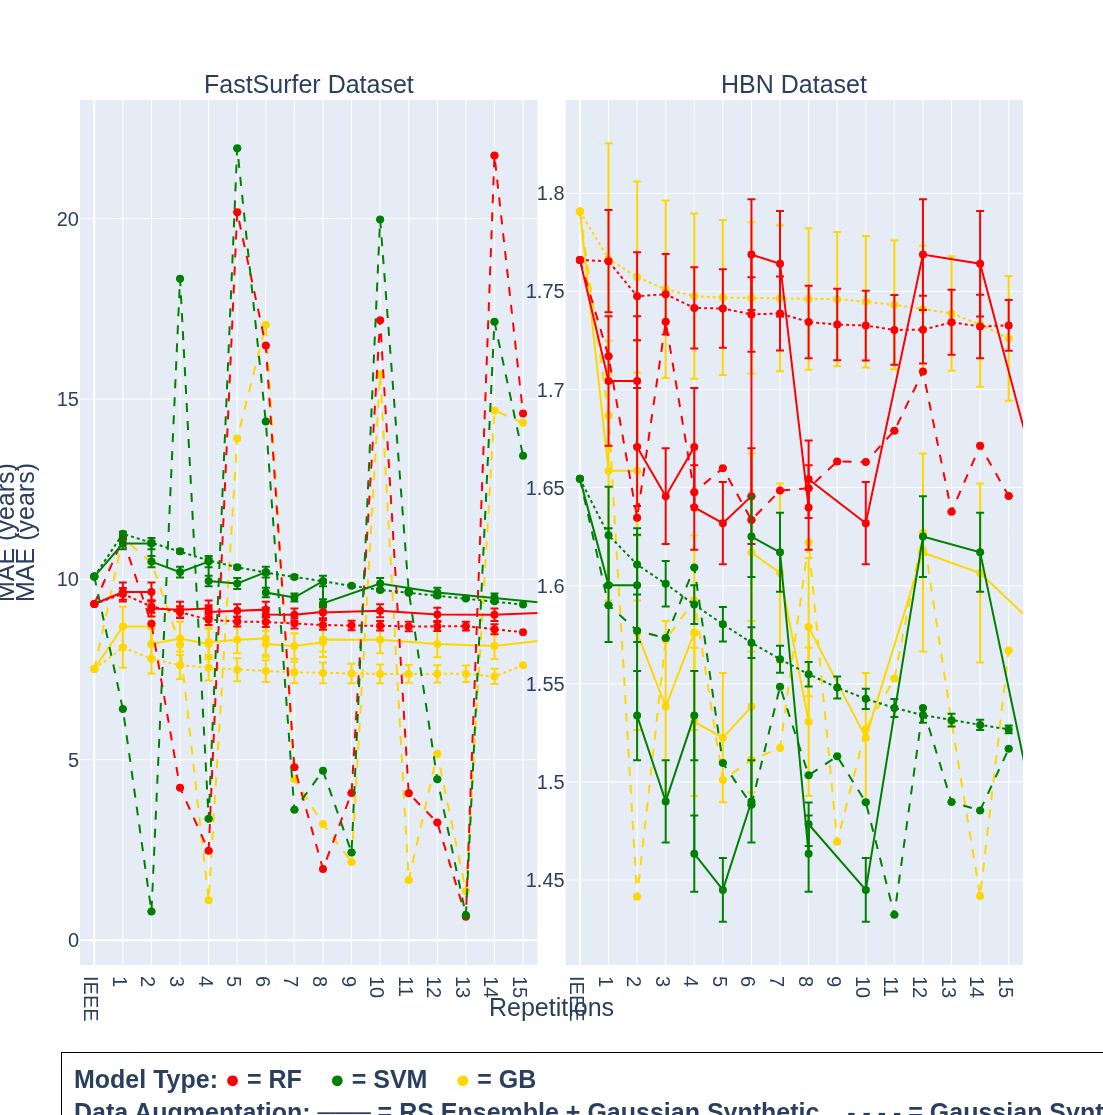

In [24]:
color_map = {
    # RF → reds
    "RF (RS Ensemble)": "red",
    "RF (RS Ensemble + Gaussian Synthetic)": "red",
    "RF (Gaussian Synthetic)": "red",
    # SVM → greens
    "SVM (RS Ensemble)": "green",
    "SVM (RS Ensemble + Gaussian Synthetic)": "green",
    "SVM (Gaussian Synthetic)": "green",
    # KNN → blues
    "KNN (RS Ensemble)": "blue",
    "KNN (RS Ensemble + Gaussian Synthetic)": "blue",
    "KNN (Gaussian Synthetic)": "blue",
    # GB → yellows
    "GB (RS Ensemble)": "gold",
    "GB (RS Ensemble + Gaussian Synthetic)": "gold",
    "GB (Gaussian Synthetic)": "gold",
}

dash_map = {
    "RS Ensemble": "dot",
    "Gaussian Synthetic": "dash",
    "RS Ensemble + Gaussian Synthetic": "solid",
}

# fig = go.Figure()
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("FastSurfer Dataset", "HBN Dataset"),
    horizontal_spacing=0.03
)

df_all = pd.concat([
    build_df(reps['fs_rf'], "RF (RS Ensemble)", 'fs_rf'),
    build_df(reps['fs_svm'], "SVM (RS Ensemble)", 'fs_svm'),
    # build_df(reps['fs_knn'], "KNN (RR Ensemble)", 'fs_knn'),
    build_df(reps['fs_gb'], "GB (RS Ensemble)", 'fs_gb'),
    # build_df(reps['fs_combo_rf'], "RF (RR Ensemble + Gaussian Synthetic)",'fs_combo_rf'),
    # build_df(reps['fs_combo_svm'], "SVM (RR Ensemble + Gaussian Synthetic)",'fs_combo_svm'),
    # # build_df(reps['fs_combo_knn'], "KNN (RR Ensemble + Gaussian Synthetic)",'fs_combo_knn'),
    # build_df(reps['fs_combo_gb'], "GB (RR Ensemble + Gaussian Synthetic)", 'fs_combo_gb'),
    build_df(reps['fs_doublecombo_rf'], "RF (RS Ensemble + Gaussian Synthetic)",'fs_doublecombo_rf'),
    build_df(reps['fs_doublecombo_svm'], "SVM (RS Ensemble + Gaussian Synthetic)",'fs_doublecombo_svm'),
    # build_df(reps['fs_doublecombo_knn'], "KNN (RR Ensemble + Gaussian Synthetic)",'fs_doublecombo_knn'),
    build_df(reps['fs_doublecombo_gb'], "GB (RS Ensemble + Gaussian Synthetic)", 'fs_doublecombo_gb'),
    build_df(reps['fs_synth_rf'], "RF (Gaussian Synthetic)", 'fs_synth_rf'),
    build_df(reps['fs_synth_svm'], "SVM (Gaussian Synthetic)", 'fs_synth_svm'),
    # build_df(reps['fs_synth_knn'], "KNN (Gaussian Synthetic)", 'fs_synth_knn'),
    build_df(reps['fs_synth_gb'], "GB (Gaussian Synthetic)", 'fs_synth_gb'),

])

# Add a trace for each model for right plot
for model in sorted(df_all['Model'].unique()):
    model_data = df_all[df_all['Model'] == model].sort_values('Repetition')
    technique = model_data['Technique'].iloc[0]
    color = color_map[model]
    dash_style = dash_map[technique]
    
    fig.add_trace(go.Scatter(
        x=model_data['Repetition'],
        y=model_data['MAE'],
        error_y=dict(
            type='data',
            array=model_data['Stdev'],
            visible=True
        ),
        mode='lines+markers',
        name=model,
        line=dict(color=color, dash=dash_style, width=2),
        marker=dict(size=8, color=color),
        legendgroup=model,
        showlegend=False,),
        row=1, col=1
    )



df_all = pd.concat([
    build_df(reps['hbn_rf'], "RF (RS Ensemble)", 'hbn_rf'),
    build_df(reps['hbn_svm'], "SVM (RS Ensemble)", 'hbn_svm'),
    # build_df(reps['hbn_knn'], "KNN (RR Ensemble)", 'hbn_knn'),
    build_df(reps['hbn_gb'], "GB (RS Ensemble)", 'hbn_gb'),
    # build_df(reps['hbn_combo_rf'], "RF (RR Ensemble + Gaussian Synthetic)", 'hbn_combo_rf'),
    # build_df(reps['hbn_combo_svm'], "SVM (RR Ensemble + Gaussian Synthetic)", 'hbn_combo_svm'),
    # # build_df(reps['hbn_combo_knn'], "KNN (RR Ensemble + Gaussian Synthetic)", 'hbn_combo_knn'),
    # build_df(reps['hbn_combo_gb'], "GB (RR Ensemble + Gaussian Synthetic)", 'hbn_combo_gb'),
    build_df(reps['hbn_doublecombo_rf'], "RF (RS Ensemble + Gaussian Synthetic)", 'hbn_doublecombo_rf'),
    build_df(reps['hbn_doublecombo_svm'], "SVM (RS Ensemble + Gaussian Synthetic)", 'hbn_doublecombo_svm'),
    # build_df(reps['hbn_doublecombo_knn'], "KNN (RR Ensemble + Gaussian Synthetic)", 'hbn_doublecombo_knn'),
    build_df(reps['hbn_doublecombo_gb'], "GB (RS Ensemble + Gaussian Synthetic)", 'hbn_doublecombo_gb'),
    build_df(reps['hbn_synth_rf'], "RF (Gaussian Synthetic)", 'hbn_synth_rf'),
    build_df(reps['hbn_synth_svm'], "SVM (Gaussian Synthetic)", 'hbn_synth_svm'),
    # build_df(reps['hbn_synth_knn'], "KNN (Gaussian Synthetic)", 'hbn_synth_knn'),
    build_df(reps['hbn_synth_gb'], "GB (Gaussian Synthetic)", 'hbn_synth_gb'),

])

# Add a trace for each model for left plot
for model in sorted(df_all['Model'].unique()):
    model_data = df_all[df_all['Model'] == model].sort_values('Repetition')
    technique = model_data['Technique'].iloc[0]
    color = color_map[model]
    dash_style = dash_map[technique]
    
    fig.add_trace(go.Scatter(
        x=model_data['Repetition'],
        y=model_data['MAE'],
        error_y=dict(
            type='data',
            array=model_data['Stdev'],
            visible=True
        ),
        mode='lines+markers',
        name=model,
        line=dict(color=color, dash=dash_style, width=2),
        marker=dict(size=8, color=color),
        legendgroup=model,
        showlegend=True
    ),
    row=1, col=2
    )
    

fig.update_xaxes(
    range=[-0.5,15.5],
    tickvals=sorted(df_all["Repetition"].unique()),
    ticktext=["IEEE" if v == 0 else str(v) for v in sorted(df_all["Repetition"].unique())],
    row=1, col=2
)
fig.update_xaxes(
    range=[-0.5,15.5],
    tickvals=sorted(df_all["Repetition"].unique()),
    ticktext=["IEEE" if v == 0 else str(v) for v in sorted(df_all["Repetition"].unique())],
    row=1, col=1
)


fig.update_layout(
    # title="MAE Across Repetitions",
    # xaxis_title="Repetitions",
    yaxis_title="MAE (years)",
    xaxis=dict(title_font=dict(size=25), tickfont=dict(size=20)),
    yaxis=dict(title_font=dict(size=25), tickfont=dict(size=20)),
    showlegend=False,  # Hide the default legend
    width=2000,
    height=1100,
    # height=800, 
    # width=1700,  # Increase width to give more space
    margin=dict(b=150)  # Add right margin to fit legend
)

# # Apply to both subplots
fig.update_xaxes(tickfont=dict(size=20))
fig.update_yaxes(tickfont=dict(size=20))
# Subplot titles
fig.for_each_annotation(lambda a: a.update(font=dict(size=25)) if a.text in ["FastSurfer Dataset", "HBN Dataset"] else ())
   
# Add shared x-axis label at the bottom
fig.add_annotation(
    text="Repetitions",
    xref="paper", yref="paper",
    x=0.5, y=-0.03,
    showarrow=False,
    xanchor="center", yanchor="top",
    font=dict(size=25)
)

# Add shared y-axis label at the left
fig.add_annotation(
    text="MAE (years)",
    xref="paper", yref="paper",
    x=-0.08, y=0.5,
    showarrow=False,
    xanchor="center", yanchor="middle",
    font=dict(size=25),
    textangle=-90  # Rotate 90 degrees
)

# Add custom legend as annotation outside the plot
fig.add_annotation(
    text="<b>Model Type: " +
         "<span style='color:red'>●</span> = RF&nbsp;&nbsp;&nbsp;&nbsp;" +
         "<span style='color:green'>●</span> = SVM&nbsp;&nbsp;&nbsp;&nbsp;" +
        #  "<span style='color:blue'>●</span> = KNN&nbsp;&nbsp;&nbsp;&nbsp;" +
         "<span style='color:gold'>●</span> = GB\t<br>" +
         "<b>Data Augmentation:&nbsp;" +
         "─── = RS Ensemble + Gaussian Synthetic&nbsp;&nbsp;&nbsp;&nbsp;" +
         "- - - - = Gaussian Synthetic&nbsp;&nbsp;&nbsp;&nbsp;" +
         "⋯⋯⋯ = RS Ensemble",
    xref="paper", yref="paper",
    x=-0.02, y=-0.1,
    showarrow=False,
    xanchor="left", yanchor="top",
    font=dict(size=25),
    bgcolor="rgba(255, 255, 255, 0.95)",
    bordercolor="black",
    borderwidth=1,
    borderpad=12,
    align="left"
)

fig.show()
# fig.write_image('./data_aug_comparison.pdf', engine="kaleido", format='pdf')
fig.write_image('./data_aug_comparison.pdf', format='pdf')


In [ ]:
# Combine all results into ONE long dataframe
def build_df(reps_dict, model_name):
    rows = []
    #replace with IEEE run?
    rows.append({"Repetition": 0, "MAE": reps_dict[1][0], "Model": model_name})
    
    for rep, values in reps_dict.items():
        if rep == 0: continue
        for v in values:
            rows.append({"Repetition": rep, "MAE": v, "Model": model_name})
    return pd.DataFrame(rows)

# df_normal_rf['Model'] = "RF (Noisy)"
# df_normal_svm['Model'] = "SVM (Noisy)"
# df_synth_rf['Model'] = "RF (Gaussian Synthetic)"
# df_synth_svm['Model'] = "SVM (Gaussian Synthetic)"


df_all = pd.concat([
    # build_df(reps['fs_rf'], "RF (RR Ensemble)"),
    # build_df(reps['fs_svm'], "SVM (RR Ensemble)"),
    # build_df(reps['fs_knn'], "KNN (RR Ensemble)"),
    # build_df(reps['fs_gb'], "GB (RR Ensemble)"),
    # build_df(reps['fs_combo_rf'], "RF (RR Ensemble + Gaussian Synthetic)"),
    # build_df(reps['fs_combo_svm'], "SVM (RR Ensemble + Gaussian Synthetic)"),
    # build_df(reps['fs_combo_knn'], "KNN (RR Ensemble + Gaussian Synthetic)"),
    # build_df(reps['fs_combo_gb'], "GB (RR Ensemble + Gaussian Synthetic)"),
    build_df(reps['fs_synth_svm'], "SVM (Gaussian Synthetic)"),
    build_df(reps['fs_synth_knn'], "KNN (Gaussian Synthetic)"),
    build_df(reps['fs_synth_gb'], "GB (Gaussian Synthetic)"),

])

# # grouped by data augmentation technique
# color_map = {
#     "RF (RR Ensemble)": "steelblue",
#     "SVM (RR Ensemble)": "royalblue",
#     "KNN (RR Ensemble)": "blue",
#     "RF (Gaussian Synthetic)": "indianred",
#     "SVM (Gaussian Synthetic)": "red",
#     "KNN (Gaussian Synthetic)": "brickred",
#     "RF (RR Ensemble + Gaussian Synthetic)": "mediumpurple",
#     "SVM (RR Ensemble + Gaussian Synthetic)": "purple",
#     "KNN (RR Ensemble + Gaussian Synthetic)": "magenta",
# }

#grouped by model type
color_map = {
    # RF → reds
    "RF (RR Ensemble)": "red",
    "RF (Gaussian Synthetic)": "indianred",
    "RF (RR Ensemble + Gaussian Synthetic)": "firebrick",
    # SVM → greens
    "SVM (RR Ensemble)": "green",
    "SVM (Gaussian Synthetic)": "limegreen",
    "SVM (RR Ensemble + Gaussian Synthetic)": "darkgreen",
    # KNN → blues
    "KNN (RR Ensemble)": "blue",
    "KNN (Gaussian Synthetic)": "slateblue",
    "KNN (RR Ensemble + Gaussian Synthetic)": "navy",
    # GB → yellows
    "GB (RR Ensemble)": "gold",
    "GB (Gaussian Synthetic)": "yellow",
    "GB (RR Ensemble + Gaussian Synthetic)": "goldenrod",
}


fig = px.box(
    df_all,
    x="Repetition",
    y="MAE",
    color="Model",
    color_discrete_map=color_map,  # <--- apply the custom colors
    points="all",
    labels={"Repetition": "Repetitions", "MAE": "MAE (years)"},
    width=1500,
    height=400
)


# fig.add_hline(
#     y=chance_mae,
#     line=dict(color="black", dash="dash"),
#     annotation_text=f"Chance level (MAE={chance_mae:.2f})",
#     annotation_position="top left"
# )


# regression_lines = [
#     (x_vals, y_vals),
#     (x_vals_svm, y_vals_svm),
#     # (x_vals_normal_rf, y_vals_normal_rf),
#     # (x_vals_normal_svm, y_vals_normal_svm),
#     (x_vals_synth_rf, y_vals_synth_rf),
#     (x_vals_synth_svm, y_vals_synth_svm),
# ]

# for (x, y) in regression_lines:
#     fig.add_trace(go.Scatter(
#         x=x, y=y, mode="lines",
#         line=dict(color="red", dash="dash"),
#         showlegend=False
#     ))

fig.update_layout(
    xaxis=dict(title_font=dict(size=20), tickfont=dict(size=16)),
    yaxis=dict(title_font=dict(size=20), tickfont=dict(size=16)),
    showlegend=True
)

fig.update_xaxes(
    tickvals=sorted(df_all["Repetition"].unique()),
    ticktext=["IEEE" if v == 0 else str(v) for v in sorted(df_all["Repetition"].unique())]
)


# print(f"SVM (Gaussian Noise) ", f"Pearson R value: {r_value_normal_svm:.3f}, p-value: {p_value_normal_svm:.3e}<br>y = {slope_normal_svm:.3f}x + {intercept_normal_svm:.3f}")
# print(f"RF (Gaussian Noise)", f"Pearson R value: {r_value_normal_rf:.3f}, p-value: {p_value_normal_rf:.3e}<br>y = {slope_normal_rf:.3f}x + {intercept_normal_rf:.3f}")

# print(f"SVM (RR Ensemble) ", f"Pearson R value: {r_value['svm']:.3f}, p-value: {p_value['svm']:.3e}<br>y = {slope['svm']:.3f}x + {intercept['svm']:.3f}")
# print(f"RF (RR Ensemble)", f"Pearson R value: {r_value['rf']:.3f}, p-value: {p_value['rf']:.3e}<br>y = {slope['rf']:.3f}x + {intercept['rf']:.3f}")

# print(f"SVM (Synthetic)", f"Pearson R value: {r_value_synth_svm:.3f}, p-value: {p_value_synth_svm:.3e}<br>y = {slope_synth_svm:.3f}x + {intercept_synth_svm:.3f}")
# print(f"RF (Synthetic)", f"Pearson R value: {r_value_synth_rf:.3f}, p-value: {p_value_synth_rf:.3e}<br>y = {slope_synth_rf:.3f}x + {intercept_synth_rf:.3f}")

# print(f"SVM (RR Ensemble + Gaussian Synthetic)", f"Pearson R value: {r_value_combo_svm:.3f}, p-value: {p_value_combo_svm:.3e}<br>y = {slope_combo_svm:.3f}x + {intercept_combo_svm:.3f}")
# print(f"RF (RR Ensemble + Gaussian Synthetic)", f"Pearson R value: {r_value_combo_rf:.3f}, p-value: {p_value_combo_rf:.3e}<br>y = {slope_combo_rf:.3f}x + {intercept_combo_rf:.3f}")

# # print(f"SVM (RR Ensemble + VAE Synthetic)", f"Pearson R value: {r_value_synth_vae_svm:.3f}, p-value: {p_value_synth_vae_svm:.3e}<br>y = {slope_synth_vae_svm:.3f}x + {intercept_synth_vae_svm:.3f}")
# # print(f"RF (RR Ensemble + VAE Synthetic)", f"Pearson R value: {r_value_synth_vae_rf:.3f}, p-value: {p_value_synth_vae_rf:.3e}<br>y = {slope_synth_vae_rf:.3f}x + {intercept_synth_vae_rf:.3f}")

fig.update_layout(height=1000)
fig.show()
fig.write_image('/home/inesgp/cnn_training/data_aug_fs.pdf', engine="kaleido", format='pdf')



In [ ]:
# Combine all results into ONE long dataframe
def build_df(reps_dict, model_name):
    rows = []
    #replace with IEEE run?
    rows.append({"Repetition": 0, "MAE": reps_dict[1][0], "Model": model_name})
    
    for rep, values in reps_dict.items():
        if rep == 0: continue
        for v in values:
            rows.append({"Repetition": rep, "MAE": v, "Model": model_name})
    return pd.DataFrame(rows)

# df_normal_rf['Model'] = "RF (Noisy)"
# df_normal_svm['Model'] = "SVM (Noisy)"
# df_synth_rf['Model'] = "RF (Gaussian Synthetic)"
# df_synth_svm['Model'] = "SVM (Gaussian Synthetic)"


df_all = pd.concat([
    build_df(reps['hbn_rf'], "RF (RR Ensemble)"),
    build_df(reps['hbn_svm'], "SVM (RR Ensemble)"),
    build_df(reps['hbn_knn'], "KNN (RR Ensemble)"),
    build_df(reps['hbn_gb'], "GB (RR Ensemble)"),
    # build_df(reps['hbn_combo_rf'], "RF (RR Ensemble + Gaussian Synthetic)"),
    # build_df(reps['hbn_combo_svm'], "SVM (RR Ensemble + Gaussian Synthetic)"),
    # build_df(reps['hbn_combo_knn'], "KNN (RR Ensemble + Gaussian Synthetic)"),
    # build_df(reps_combo_rf, "RF (RR Ensemble + Gaussian Synthetic)"),
    # build_df(reps_combo_svm, "SVM (RR Ensemble + Gaussian Synthetic)"),
    build_df(reps['hbn_synth_rf'], "RF (Gaussian Synthetic)"),
    build_df(reps['hbn_synth_svm'], "SVM (Gaussian Synthetic)"),
    build_df(reps['hbn_synth_knn'], "KNN (Gaussian Synthetic)"),
    build_df(reps['hbn_synth_gb'], "GB (Gaussian Synthetic)"),

])

#grouped by model type
color_map = {
    # RF → reds
    "RF (RR Ensemble)": "red",
    "RF (Gaussian Synthetic)": "indianred",
    "RF (RR Ensemble + Gaussian Synthetic)": "firebrick",
    # SVM → greens
    "SVM (RR Ensemble)": "green",
    "SVM (Gaussian Synthetic)": "limegreen",
    "SVM (RR Ensemble + Gaussian Synthetic)": "darkgreen",
    # KNN → blues
    "KNN (RR Ensemble)": "blue",
    "KNN (Gaussian Synthetic)": "royalblue",
    "KNN (RR Ensemble + Gaussian Synthetic)": "navy",
    # GB → yellows
    "GB (RR Ensemble)": "gold",
    "GB (Gaussian Synthetic)": "khaki",
    "GB (RR Ensemble + Gaussian Synthetic)": "goldenrod",
}


fig = px.box(
    df_all,
    x="Repetition",
    y="MAE",
    color="Model",
    color_discrete_map=color_map,  # <--- apply the custom colors
    points="all",
    labels={"Repetition": "Repetitions", "MAE": "MAE (years)"},
    width=1500,
    height=400
)


# fig.add_hline(
#     y=chance_mae,
#     line=dict(color="black", dash="dash"),
#     annotation_text=f"Chance level (MAE={chance_mae:.2f})",
#     annotation_position="top left"
# )


# regression_lines = [
#     (x_vals, y_vals),
#     (x_vals_svm, y_vals_svm),
#     # (x_vals_normal_rf, y_vals_normal_rf),
#     # (x_vals_normal_svm, y_vals_normal_svm),
#     (x_vals_synth_rf, y_vals_synth_rf),
#     (x_vals_synth_svm, y_vals_synth_svm),
# ]

# for (x, y) in regression_lines:
#     fig.add_trace(go.Scatter(
#         x=x, y=y, mode="lines",
#         line=dict(color="red", dash="dash"),
#         showlegend=False
#     ))

fig.update_layout(
    xaxis=dict(title_font=dict(size=20), tickfont=dict(size=16)),
    yaxis=dict(title_font=dict(size=20), tickfont=dict(size=16)),
    showlegend=True
)

fig.update_xaxes(
    tickvals=sorted(df_all["Repetition"].unique()),
    ticktext=["IEEE" if v == 0 else str(v) for v in sorted(df_all["Repetition"].unique())]
)


# print(f"SVM (Gaussian Noise) ", f"Pearson R value: {r_value_normal_svm:.3f}, p-value: {p_value_normal_svm:.3e}<br>y = {slope_normal_svm:.3f}x + {intercept_normal_svm:.3f}")
# print(f"RF (Gaussian Noise)", f"Pearson R value: {r_value_normal_rf:.3f}, p-value: {p_value_normal_rf:.3e}<br>y = {slope_normal_rf:.3f}x + {intercept_normal_rf:.3f}")

# print(f"SVM (RR Ensemble) ", f"Pearson R value: {r_value['svm']:.3f}, p-value: {p_value['svm']:.3e}<br>y = {slope['svm']:.3f}x + {intercept['svm']:.3f}")
# print(f"RF (RR Ensemble)", f"Pearson R value: {r_value['rf']:.3f}, p-value: {p_value['rf']:.3e}<br>y = {slope['rf']:.3f}x + {intercept['rf']:.3f}")

# print(f"SVM (Synthetic)", f"Pearson R value: {r_value_synth_svm:.3f}, p-value: {p_value_synth_svm:.3e}<br>y = {slope_synth_svm:.3f}x + {intercept_synth_svm:.3f}")
# print(f"RF (Synthetic)", f"Pearson R value: {r_value_synth_rf:.3f}, p-value: {p_value_synth_rf:.3e}<br>y = {slope_synth_rf:.3f}x + {intercept_synth_rf:.3f}")

# print(f"SVM (RR Ensemble + Gaussian Synthetic)", f"Pearson R value: {r_value_combo_svm:.3f}, p-value: {p_value_combo_svm:.3e}<br>y = {slope_combo_svm:.3f}x + {intercept_combo_svm:.3f}")
# print(f"RF (RR Ensemble + Gaussian Synthetic)", f"Pearson R value: {r_value_combo_rf:.3f}, p-value: {p_value_combo_rf:.3e}<br>y = {slope_combo_rf:.3f}x + {intercept_combo_rf:.3f}")

# # print(f"SVM (RR Ensemble + VAE Synthetic)", f"Pearson R value: {r_value_synth_vae_svm:.3f}, p-value: {p_value_synth_vae_svm:.3e}<br>y = {slope_synth_vae_svm:.3f}x + {intercept_synth_vae_svm:.3f}")
# # print(f"RF (RR Ensemble + VAE Synthetic)", f"Pearson R value: {r_value_synth_vae_rf:.3f}, p-value: {p_value_synth_vae_rf:.3e}<br>y = {slope_synth_vae_rf:.3f}x + {intercept_synth_vae_rf:.3f}")

fig.update_layout(height=1000)
fig.show()
fig.write_image('/home/inesgp/cnn_training/data_aug_baseline_hbn.pdf', engine="kaleido", format='pdf')
